<a href="https://colab.research.google.com/github/Rick2898/Series_tiempo_prom_movil-/blob/main/ACTIVIDAD_1/Entrega.ipynb">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" 
    alt="Open In Colab"/>
</a>

# Implementacion de Holt Winters

#### Carlos Preciado
#### Jefferson Martinez
#### Ricardo Vargas

En el siguiente notebook se desarrolla la implementacion del mejor pronostico para los proximos seis meses con ayuda del modelo de holtwinters. La data para la implementacion es: la informacion de personas ocupadas en miles de personas para las principales 13 ciudades de Colombia en su archivo <code>datosEmpleo.xlsx</code>

## Carga de librerias y data

In [65]:
import numpy as np 
import pandas as pd 
from matplotlib import pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose  # descomposicion 
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from sklearn.metrics import mean_squared_error
import itertools

In [66]:

df_empleo= pd.read_excel("https://raw.githubusercontent.com/dagudelo30/Series-de-tiempo---Javeriana-Cali/main/intro-moving_average/datosEmpleo.xlsx",index_col='mes',parse_dates=True)
df_empleo.head()
df_empleo.shape

(222, 4)

In [67]:
df_empleo.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 222 entries, 2001-01-01 to 2019-06-01
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   TD_13ciudades  222 non-null    float64
 1   Ocupados       222 non-null    float64
 2   Desocupados    222 non-null    float64
 3   Inactivos      222 non-null    float64
dtypes: float64(4)
memory usage: 8.7 KB


## Division train test

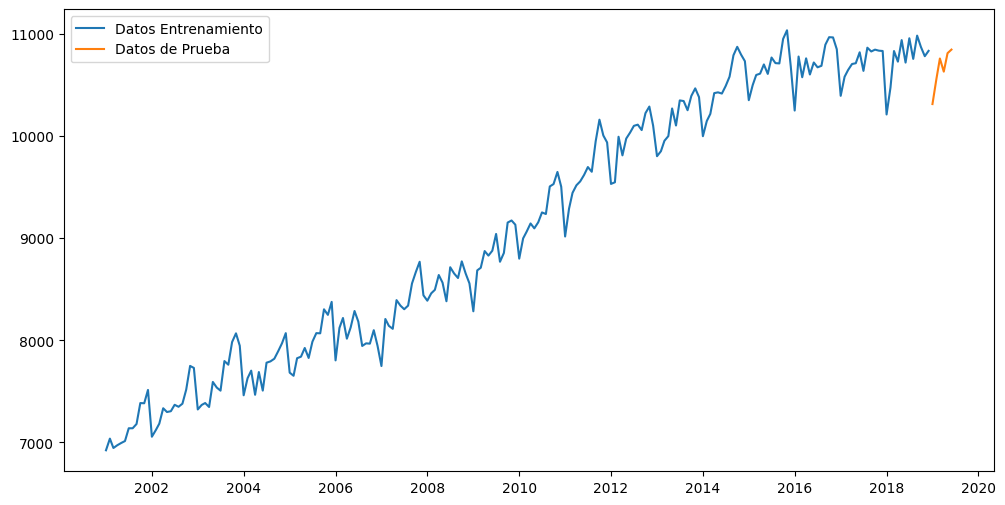

In [68]:
train_len = 216
train_td = df_empleo[["Ocupados"]][:train_len]
test_td  = df_empleo[["Ocupados"]][train_len:]

fig = plt.figure(figsize=(12, 6))
plt.plot(train_td, label="Datos Entrenamiento")
plt.plot(test_td,  label="Datos de Prueba")
plt.legend()
plt.show()

## Implementacion Holt Winters Aditivo

In [69]:
# ── Modelo Holt-Winters ADITIVO ──
# endog = variable que queremos pronosticar en nuestro caso el train
# error=el error se suma al modelo
# trend= muy importante ya que se refiere a que la tendencia es aditiva y aqui puede cambiarse
# seasonal = la estacionalidad en este caso tambien es aditiva 


ets_model = ETSModel(
    endog=train_td["Ocupados"],
    error="add", trend="add", seasonal="add"
)
ets_result = ets_model.fit()

# Pronósticos para 14 periodos
point_forecast = ets_result.forecast(6)

# Intervalos de confianza al 95%
ci = ets_result.get_prediction(
    start=point_forecast.index[0],# obtiene pronostico desde el primer periodo
    end=point_forecast.index[-1] # hasta el ultimo periodo
)
conf_forecast = ci.pred_int(alpha=0.05) # calcula al 95%
limits = ci.predicted_mean  # extrae la media predicha

preds_hw_add = pd.concat([limits, conf_forecast], axis=1) # concatena los resultados con los intervalos
preds_hw_add.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_hw_add)

c:\Users\jeam2\Downloads\maestria de Ciencia de Datos\II-semestre segundo_corte\series de tiempo\entrega 2\Series_Tiempo\ACTIVIDAD_2\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


            Point_forecast      lower_95      upper_95
2019-01-01    10349.038256  10090.537075  10607.539437
2019-02-01    10624.647272  10350.485455  10898.809090
2019-03-01    10770.076785  10481.098911  11059.054659
2019-04-01    10786.211615  10483.138374  11089.284856
2019-05-01    10870.784042  10554.239833  11187.328251
2019-06-01    10828.720945  10499.253569  11158.188320


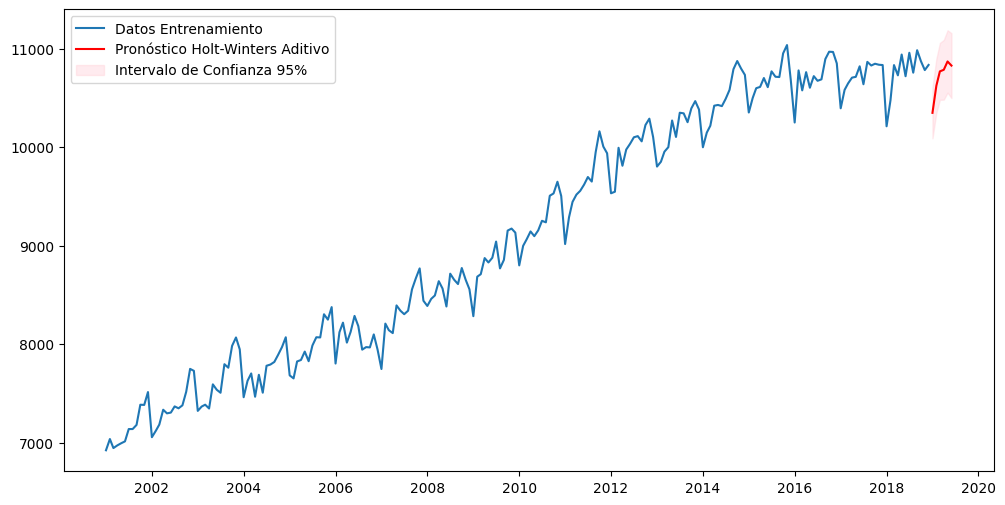

In [70]:
plt.figure(figsize=(12, 6))
plt.plot(train_td, label="Datos Entrenamiento")
plt.plot(preds_hw_add['Point_forecast'], label="Pronóstico Holt-Winters Aditivo", color='red')
plt.fill_between(preds_hw_add.index, preds_hw_add['lower_95'], preds_hw_add['upper_95'], color='pink', alpha=0.3, label="Intervalo de Confianza 95%")
plt.legend()
plt.show()                 

In [71]:
# Parámetros estimados y RMSE
print(ets_result.alpha, ets_result.beta, ets_result.gamma)

rmse_hw_add = np.sqrt(mean_squared_error(
    test_td, preds_hw_add['Point_forecast']
))
print(rmse_hw_add)

0.3532848405931927 3.532848405931927e-05 0.2970683164020024
74.40864219135457


## Implementacion Hotl Winters Multiplicativo

In [72]:
# ── Modelo Holt-Winters MULTIPLICATIVO ──
# endog = variable que queremos pronosticar en nuestro caso el train
# error=el error se suma al modelo
# trend= muy importante ya que se refiere a que la tendencia es aditiva y aqui puede cambiarse
# seasonal = la estacionalidad en este caso tambien es aditiva 


ets_model = ETSModel(
    endog=train_td["Ocupados"],
    error="add", trend=None, seasonal="mul"
)
ets_result_2 = ets_model.fit()

# Pronósticos para 6 periodos
point_forecast = ets_result.forecast(6)

# Intervalos de confianza al 95%
ci = ets_result_2.get_prediction(
    start=point_forecast.index[0],# obtiene pronostico desde el primer periodo
    end=point_forecast.index[-1] # hasta el ultimo periodo
)
conf_forecast = ci.pred_int(alpha=0.05) # calcula al 95%
limits = ci.predicted_mean  # extrae la media predicha

preds_hw_mul = pd.concat([limits, conf_forecast], axis=1) # concatena los resultados con los intervalos
preds_hw_mul.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_hw_mul)

c:\Users\jeam2\Downloads\maestria de Ciencia de Datos\II-semestre segundo_corte\series de tiempo\entrega 2\Series_Tiempo\ACTIVIDAD_2\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


            Point_forecast      lower_95      upper_95
2019-01-01    10325.781779  10102.474477  10563.005035
2019-02-01    10527.749215  10263.994292  10793.476474
2019-03-01    10611.310519  10306.158583  10913.775782
2019-04-01    10620.935104  10305.990458  10936.992644
2019-05-01    10689.617939  10348.252472  11052.819194
2019-06-01    10645.660988  10293.875214  11012.398511


In [73]:
# Parámetros estimados y RMSE
print(ets_result_2.alpha, ets_result_2.gamma)

rmse_hw_mul = np.sqrt(mean_squared_error(
    test_td, preds_hw_mul['Point_forecast']
))
print(rmse_hw_mul)

0.5975177743043917 4.0248222569560836e-05
115.22873454150286


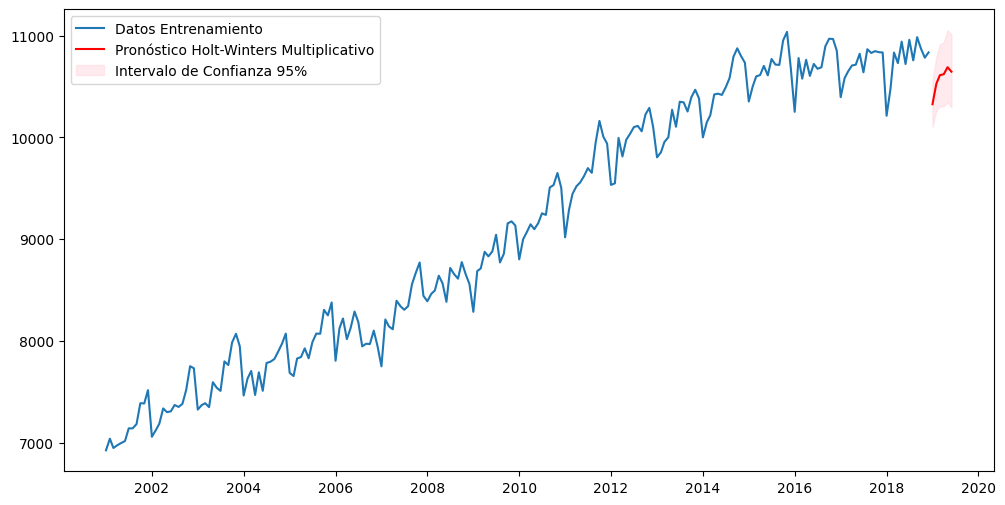

In [74]:
plt.figure(figsize=(12, 6))
plt.plot(train_td, label="Datos Entrenamiento")
plt.plot(preds_hw_mul['Point_forecast'], label="Pronóstico Holt-Winters Multiplicativo", color='red')
plt.fill_between(preds_hw_mul.index, preds_hw_mul['lower_95'], preds_hw_mul['upper_95'], color='pink', alpha=0.3, label="Intervalo de Confianza 95%")
plt.legend()
plt.show()        

In [75]:

ets_model = ETSModel(
    endog=train_td["Ocupados"],
    error="mul", trend=None, seasonal="mul"
)
ets_result_3 = ets_model.fit()

# Pronósticos para 6 periodos
point_forecast = ets_result.forecast(6)

# Intervalos de confianza al 95%
ci = ets_result_3.get_prediction(
    start=point_forecast.index[0],# obtiene pronostico desde el primer periodo
    end=point_forecast.index[-1] # hasta el ultimo periodo
)
conf_forecast = ci.pred_int(alpha=0.05) # calcula al 95%
limits = ci.predicted_mean  # extrae la media predicha

preds_hw_error_mul_tend_NA_station_mul = pd.concat([limits, conf_forecast], axis=1) # concatena los resultados con los intervalos
preds_hw_error_mul_tend_NA_station_mul.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_hw_error_mul_tend_NA_station_mul)

c:\Users\jeam2\Downloads\maestria de Ciencia de Datos\II-semestre segundo_corte\series de tiempo\entrega 2\Series_Tiempo\ACTIVIDAD_2\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


            Point_forecast      lower_95      upper_95
2019-01-01    10324.805425  10035.646888  10604.511484
2019-02-01    10522.829105  10215.389086  10853.884235
2019-03-01    10595.191016  10231.933845  10962.401419
2019-04-01    10596.282255  10204.574711  11021.357767
2019-05-01    10671.641019  10234.507555  11102.473568
2019-06-01    10622.728256  10146.475725  11089.310798


In [76]:
# Parámetros estimados y RMSE
print(ets_result_3.alpha, ets_result_3.gamma)

rmse_hw_error_mul_tend_NA_station_mul = np.sqrt(mean_squared_error(
    test_td, preds_hw_error_mul_tend_NA_station_mul['Point_forecast']
))
print(rmse_hw_error_mul_tend_NA_station_mul)

0.6251134101839402 3.748865898160598e-05
129.59199377333363


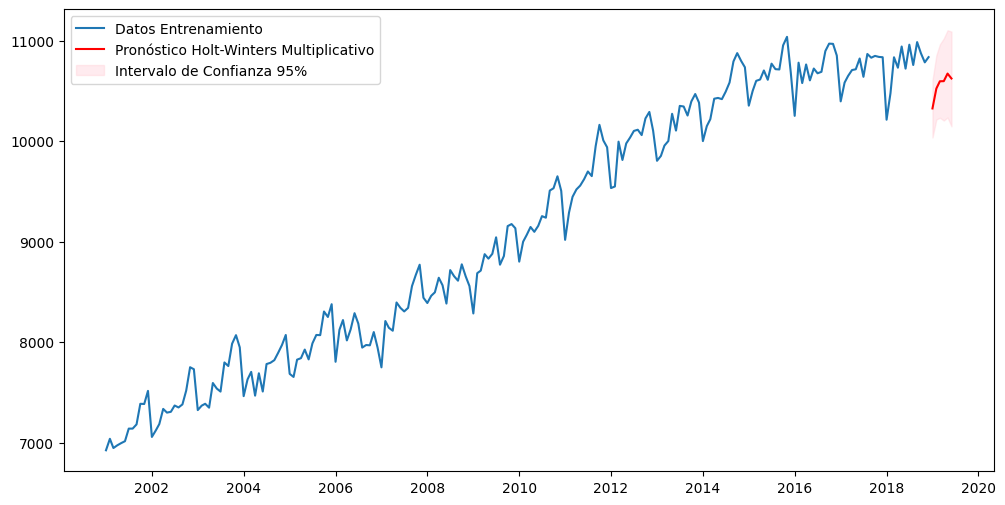

In [77]:
plt.figure(figsize=(12, 6))
plt.plot(train_td, label="Datos Entrenamiento")
plt.plot(preds_hw_error_mul_tend_NA_station_mul['Point_forecast'], label="Pronóstico Holt-Winters Multiplicativo", color='red')
plt.fill_between(preds_hw_error_mul_tend_NA_station_mul.index, preds_hw_error_mul_tend_NA_station_mul['lower_95'], preds_hw_error_mul_tend_NA_station_mul['upper_95'], color='pink', alpha=0.3, label="Intervalo de Confianza 95%")
plt.legend()
plt.show()    

In [78]:
ets_model = ETSModel(
    endog=train_td["Ocupados"],
    error="add", trend="mul", seasonal="mul"
)
ets_result_4 = ets_model.fit()

# Pronósticos para 6 periodos
point_forecast = ets_result_4.forecast(6)

# Intervalos de confianza al 95%
ci = ets_result_4.get_prediction(
    start=point_forecast.index[0],# obtiene pronostico desde el primer periodo
    end=point_forecast.index[-1] # hasta el ultimo periodo
)
conf_forecast = ci.pred_int(alpha=0.05) # calcula al 95%
limits = ci.predicted_mean  # extrae la media predicha

preds_hw_error_add_tend_mul_station_mul = pd.concat([limits, conf_forecast], axis=1) # concatena los resultados con los intervalos
preds_hw_error_add_tend_mul_station_mul.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_hw_error_add_tend_mul_station_mul)

c:\Users\jeam2\Downloads\maestria de Ciencia de Datos\II-semestre segundo_corte\series de tiempo\entrega 2\Series_Tiempo\ACTIVIDAD_2\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


            Point_forecast      lower_95      upper_95
2019-01-01    10367.425903  10143.057225  10580.461236
2019-02-01    10585.339728  10314.632261  10820.467978
2019-03-01    10687.360261  10384.565638  10967.177534
2019-04-01    10715.093809  10396.295321  11023.425454
2019-05-01    10802.125310  10454.885529  11141.014830
2019-06-01    10775.756904  10427.102870  11126.628866


In [79]:
# Parámetros estimados y RMSE
print(ets_result_4.alpha, ets_result_4.gamma)

rmse_hw_error_add_tend_mul_station_mul = np.sqrt(mean_squared_error(
    test_td, preds_hw_error_add_tend_mul_station_mul['Point_forecast']
))
print(rmse_hw_error_add_tend_mul_station_mul)

0.5253405498899031 4.746594501100969e-05
59.42340592249937


In [80]:


# ==========================================
# 1. PREPARACIÓN Y VALIDACIÓN (Últimos 6 meses para test)
# ==========================================
# Forzamos que el set de prueba sean los últimos 6 meses para evaluar el horizonte pedido
y_train = train_td["Ocupados"].dropna()
y_test = test_td["Ocupados"].dropna()

errores = ["add", "mul"]
tendencias = ["add", "mul", None]
estacionalidades = ["add", "mul", None]

mejor_rmse = float("inf")
mejor_config = {}

print("Buscando la mejor configuración basada en un horizonte de 6 meses...")

for err, trend, seas in itertools.product(errores, tendencias, estacionalidades):
    try:
        # Evaluamos el rendimiento en el set de validación de 6 meses
        model = ETSModel(y_train, error=err, trend=trend, seasonal=seas, initialization_method="estimated")
        result = model.fit(disp=False, maxiter=1000)
        
        # Pronóstico para los 6 meses del set de prueba
        point_forecast = result.forecast(steps=6)
        rmse = np.sqrt(mean_squared_error(y_test, point_forecast))
        
        if rmse < mejor_rmse:
            mejor_rmse = rmse
            mejor_config = {"error": err, "trend": trend, "seasonal": seas}
    except:
        continue

print(f"Mejor configuración encontrada: Error={ets_result.alpha}, Tendencia={ets_result.beta}, Estacionalidad={ets_result.gamma} con RMSE={mejor_rmse:.4f}")
print(f"\nGanador Validación -> Error: {mejor_config['error']}, Tendencia: {mejor_config['trend']}, Estacionalidad: {mejor_config['seasonal']}")
print(f"RMSE en validación: {mejor_rmse:.4f}\n")

# ==========================================
# 2. REENTRENAMIENTO Y PRONÓSTICO FUTURO (Próximos 6 meses)
# ==========================================
# Para predecir el futuro real, unimos todo el dataset histórico disponible
df_completo = pd.concat([train_td, test_td])["Ocupados"].dropna()

# Ajustamos el modelo ganador con el 100% de los datos
modelo_final = ETSModel(
    df_completo, 
    error=mejor_config['error'], 
    trend=mejor_config['trend'], 
    seasonal=mejor_config['seasonal'], 
    initialization_method="estimated"
)
resultado_final = modelo_final.fit(disp=False)

# Proyectamos los próximos 6 meses reales hacia el futuro
pronostico_futuro = resultado_final.forecast(steps=6)

# Calculamos intervalos de confianza al 95% para el futuro
ci_futuro = resultado_final.get_prediction(start=pronostico_futuro.index[0], end=pronostico_futuro.index[-1])
limites_futuro = ci_futuro.pred_int(alpha=0.05)

# Tabla final de proyecciones exigida por el ejercicio
tabla_proyecciones = pd.concat([pronostico_futuro, limites_futuro], axis=1)
tabla_proyecciones.columns = ['Pronostico_Ocupados', 'Limite_Inferior_95', 'Limite_Superior_95']

print("--- PROYECCIONES PARA LOS PRÓXIMOS 6 MESES ---")
print(tabla_proyecciones)

Buscando la mejor configuración basada en un horizonte de 6 meses...


c:\Users\jeam2\Downloads\maestria de Ciencia de Datos\II-semestre segundo_corte\series de tiempo\entrega 2\Series_Tiempo\ACTIVIDAD_2\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\jeam2\Downloads\maestria de Ciencia de Datos\II-semestre segundo_corte\series de tiempo\entrega 2\Series_Tiempo\ACTIVIDAD_2\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\jeam2\Downloads\maestria de Ciencia de Datos\II-semestre segundo_corte\series de tiempo\entrega 2\Series_Tiempo\ACTIVIDAD_2\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\jeam2\Downloads\maestria de Cie

Mejor configuración encontrada: Error=0.3532848405931927, Tendencia=3.532848405931927e-05, Estacionalidad=0.2970683164020024 con RMSE=59.4234

Ganador Validación -> Error: add, Tendencia: mul, Estacionalidad: mul
RMSE en validación: 59.4234

--- PROYECCIONES PARA LOS PRÓXIMOS 6 MESES ---
            Pronostico_Ocupados  Limite_Inferior_95  Limite_Superior_95
2019-07-01         10915.516516        10679.276285        11149.093209
2019-08-01         10903.903266        10655.735127        11158.398844
2019-09-01         10997.557848        10729.146144        11290.402073
2019-10-01         11140.435436        10848.295321        11459.111976
2019-11-01         11165.653329        10847.236078        11511.890054
2019-12-01         11069.928152        10703.655210        11425.273182
